# SGC Brain Graph Super-Resolution Baseline

## Imports

In [1]:
import random
from time import perf_counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import KFold

from utils.MatrixVectorizer import MatrixVectorizer
from utils.plot_chart import plot_fold_metrics
from utils.training import compute_metrics

# Reproducibility (kept from tutorial)
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Constants

In [2]:
LR_NODES   = 160          # 160×160 adjacency matrices
FLAT_DIM   = LR_NODES * LR_NODES   # 25 600  (flattened S^K X)
HIDDEN_DIM = 256
SGC_K      = 2
NUM_EPOCHS = 300
LR         = 0.01

## 1) Data Loading and Safe Preprocessing
Replaces `TUDataset` / `Planetoid` loading from the tutorial.

Each LR sample is a vectorised 160×160 adjacency matrix (12 720 values).  
Each HR sample is the regression target vector (35 778 values).

In [3]:
def sanitize_vectors(v: np.ndarray) -> np.ndarray:
    """Replace NaNs with 0 and clip negatives – safe graph preprocessing."""
    v = np.nan_to_num(v, nan=0.0)
    v = np.clip(v, 0, None)
    return v


def load_data(lr_path: str, hr_path: str):
    """
    Load LR and HR CSV files (numeric index header → skiprows=1), sanitize.
    Returns two numpy arrays of shape (N, edge_dim_lr) and (N, edge_dim_hr).
    """
    lr = np.loadtxt(lr_path, delimiter=",", skiprows=1, dtype=np.float32)
    hr = np.loadtxt(hr_path, delimiter=",", skiprows=1, dtype=np.float32)
    lr = sanitize_vectors(lr)
    hr = sanitize_vectors(hr)
    return lr, hr


print("Loading data...")
lr_train, hr_train = load_data("data/lr_train.csv", "data/hr_train.csv")
print(f"  LR shape: {lr_train.shape}")   # (167, 12720)
print(f"  HR shape: {hr_train.shape}")   # (167, 35778)

HR_OUT_DIM = hr_train.shape[1]           # inferred from the file (35 778)

Loading data...
  LR shape: (167, 12720)
  HR shape: (167, 35778)


## 2) Adjacency Normalisation
Identical to the normalisation block inside `preprocess_nc_dataset` in Tutorial Section 2.4.

$$S = \tilde{D}^{-1/2}(A + I)\tilde{D}^{-1/2}$$

In [4]:
def normalize_adj(A: torch.Tensor) -> torch.Tensor:
    """
    Add self-loops and compute S = D^{-1/2} (A + I) D^{-1/2}.
    Kept identical to the tutorial normalisation.
    """
    A_hat = A + torch.eye(A.size(0), device=A.device)
    epsilon = 1e-5                        # avoid division by zero (same as tutorial)
    d = A_hat.sum(1) + epsilon
    D_inv_sqrt = torch.diag(torch.pow(d, -0.5))
    S = D_inv_sqrt @ A_hat @ D_inv_sqrt
    return S

## 3) SGC Precomputation
Directly adapted from `sgc_precompute` in Tutorial Section 2.2.

$$\hat{X} = S^K X$$

Since $S^K X$ requires no weight it is a pure feature pre-processing step, exactly as in the tutorial.

In [5]:
def sgc_precompute(X: torch.Tensor, S: torch.Tensor, deg: int):
    """
    Precomputes the k-step graph propagation  S^K * X.

    Params:
        X   (tensor): Node feature matrix of shape (N x d)
        S   (tensor): Normalised + self-looped adj. matrix of shape (N x N)
        deg (int)   : Propagation degree K

    Returns:
        (preprocessed features of shape (N x d),  elapsed seconds)
    """
    start = perf_counter()
    feat = X
    for _ in range(deg):
        feat = S @ feat
    elapsed = perf_counter() - start
    return feat, elapsed

## 4) Per-Sample Feature Precomputation
For every subject we:
1. Reconstruct the 160×160 adjacency matrix from its LR vector.
2. Use **A itself** as the node feature matrix X.
3. Compute $S^K X$ → shape (160, 160).
4. Flatten → shape (25 600,).

This replaces the single-graph precomputation loop from Tutorial Section 2.6.

In [6]:
def precompute_all(lr_vecs: np.ndarray, K: int = 2) -> torch.Tensor:
    """
    For each sample:
      - reconstruct 160×160 adjacency matrix A from its LR vector
      - use A itself as the node feature matrix X
      - compute S^K X  → shape (160, 160)
      - flatten        → shape (25 600,)

    Returns tensor of shape (N, LR_NODES * LR_NODES).
    """
    feats = []
    for v in lr_vecs:
        A_np = MatrixVectorizer.anti_vectorize(v, LR_NODES).astype(np.float32)
        A    = torch.tensor(A_np, device=device)
        S    = normalize_adj(A)
        X_pre, _ = sgc_precompute(A, S, K)   # (160, 160)
        feats.append(X_pre.view(-1))          # flatten → (25 600,)
    return torch.stack(feats)                 # (N, 25 600)


print("=== Precomputing SGC features for all samples ===")
t0    = perf_counter()
X_all = precompute_all(lr_train, K=SGC_K)
print(f"Done in {perf_counter() - t0:.2f}s.  Feature tensor shape: {X_all.shape}")

y_all = torch.tensor(hr_train, dtype=torch.float32, device=device)
X_all = X_all.to(device)

=== Precomputing SGC features for all samples ===
Done in 1.20s.  Feature tensor shape: torch.Size([167, 25600])


## 5) SGC Regression Model
Adapted from Tutorial Section 2.1; the only change is a **regression output** instead of class logits.

A single `Linear(25 600, 35 778)` would require ~3.5 GB just for the weight matrix, so the "optionally two layers" allowance is used:

```
Linear(25 600, 256) → ReLU → Linear(256, 35 778)
```

In [7]:
class SGC(nn.Module):
    """
    Simple Graph Convolution as regression on precomputed propagated features.
    Adapted from tutorial SGC (Section 2.1); the only change is regression output
    and a small bottleneck to keep the parameter count manageable.
    """
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super(SGC, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = F.relu(self.fc1(x))
        return self.fc2(h)

## 6) Training Loop
Identical structure to the Tutorial Section 2.7 SGC training epoch loop.

In [8]:
def train_sgc(model, X_train, y_train, optimizer, loss_fn, num_epochs):
    """
    Train SGC on precomputed features.
    Direct parallel of the epoch loop in Tutorial Section 2.7.
    """
    loss_values = []
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()

        output = model(X_train)
        loss   = loss_fn(output, y_train)

        loss.backward()
        optimizer.step()

        loss_values.append(loss.item())
        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs},  Loss: {loss.item():.6f}")

    return loss_values

## 7) 3-Fold Cross-Validation
Replaces the single fixed split used in Tutorial Sections 2.7–2.10.
For each fold: train → predict on validation → compute graph metrics via `utils/training.compute_metrics`.

In [9]:
kf      = KFold(n_splits=3, shuffle=True, random_state=seed)
loss_fn = nn.L1Loss()

all_fold_metrics = []
fold_mae_list    = []

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_all.cpu())):
    print(f"\n==== Fold {fold_idx + 1} ====")

    X_train_fold = X_all[train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold   = X_all[val_idx]
    y_val_fold   = y_all[val_idx]

    # Re-initialise model for each fold (same pattern as tutorial per-config reset)
    torch.manual_seed(seed)
    model     = SGC(FLAT_DIM, HIDDEN_DIM, HR_OUT_DIM).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    print("\nTraining:")
    train_sgc(model, X_train_fold, y_train_fold, optimizer, loss_fn, NUM_EPOCHS)

    print("\nEvaluating:")
    with torch.no_grad():
        model.eval()
        preds = model(X_val_fold).cpu().numpy()
        gt    = y_val_fold.cpu().numpy()

    preds   = sanitize_vectors(preds)
    metrics = compute_metrics(preds, gt, sanitize_fn=sanitize_vectors)
    all_fold_metrics.append(metrics)

    fold_mae_list.append(metrics["MAE"])
    print(f"Fold {fold_idx + 1} MAE: {metrics['MAE']:.6f}")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")


==== Fold 1 ====

Training:
  Epoch 50/300,  Loss: 0.148199
  Epoch 100/300,  Loss: 0.140270
  Epoch 150/300,  Loss: 0.140222
  Epoch 200/300,  Loss: 0.140223
  Epoch 250/300,  Loss: 0.140220
  Epoch 300/300,  Loss: 0.140223

Evaluating:
Fold 1 MAE: 0.135704
  MAE: 0.135704
  PCC: 0.625923
  JSD: 0.288975
  MAE(PC): 0.000572
  MAE(EC): 0.013721
  MAE(BC): 0.020389
  MAE(CC): 0.141652
  MAE(DC): 0.185250

==== Fold 2 ====

Training:
  Epoch 50/300,  Loss: 0.143146
  Epoch 100/300,  Loss: 0.135385
  Epoch 150/300,  Loss: 0.135339
  Epoch 200/300,  Loss: 0.135337
  Epoch 250/300,  Loss: 0.135337
  Epoch 300/300,  Loss: 0.135338

Evaluating:
Fold 2 MAE: 0.145321
  MAE: 0.145321
  PCC: 0.592549
  JSD: 0.301728
  MAE(PC): 0.000578
  MAE(EC): 0.014175
  MAE(BC): 0.024892
  MAE(CC): 0.146608
  MAE(DC): 0.193121

==== Fold 3 ====

Training:
  Epoch 50/300,  Loss: 0.146321
  Epoch 100/300,  Loss: 0.138607
  Epoch 150/300,  Loss: 0.138568
  Epoch 200/300,  Loss: 0.138567
  Epoch 250/300,  Loss: 

## 8) Summary and Results
Analogous to the comparison block in Tutorial Section 2.11.

=== 3-Fold Cross-Validation Summary ===
  Fold 1 MAE: 0.135704
  Fold 2 MAE: 0.145321
  Fold 3 MAE: 0.139038
  Mean MAE:   0.140021
Figure saved to figs/sgc_baseline_cv_metrics.png


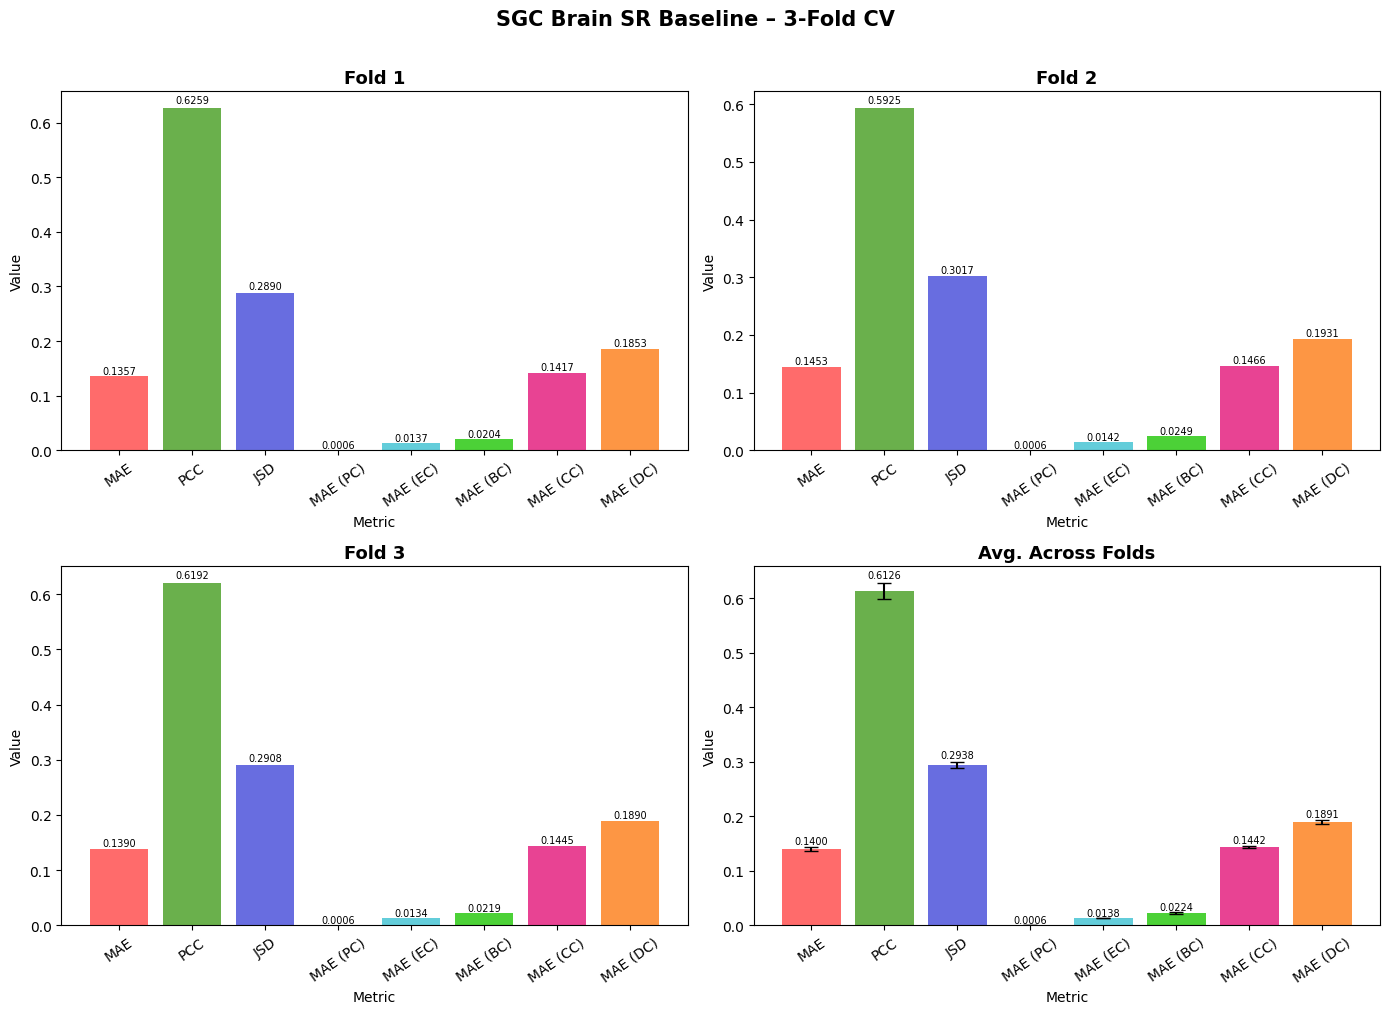

In [10]:
print("=== 3-Fold Cross-Validation Summary ===")
for i, mae in enumerate(fold_mae_list, 1):
    print(f"  Fold {i} MAE: {mae:.6f}")
print(f"  Mean MAE:   {np.mean(fold_mae_list):.6f}")

# Plot metrics chart using the shared utility
fig = plot_fold_metrics(
    all_fold_metrics,
    title="SGC Brain SR Baseline – 3-Fold CV",
    save_path="figs/sgc_baseline_cv_metrics.png",
)
fig.show()

In [11]:
metric_keys = list(all_fold_metrics[0].keys())

print(f"{'Metric':<12}  {'Mean':>10}  {'Std':>10}  {'Summary'}")
print("-" * 55)
for k in metric_keys:
    values = [f[k] for f in all_fold_metrics]
    mean   = np.mean(values)
    std    = np.std(values)
    print(f"{k:<12}  {mean:>10.6f}  {std:>10.6f}  {mean:.4f} ± {std:.4f}")

Metric              Mean         Std  Summary
-------------------------------------------------------
MAE             0.140021    0.003987  0.1400 ± 0.0040
PCC             0.612571    0.014418  0.6126 ± 0.0144
JSD             0.293837    0.005630  0.2938 ± 0.0056
MAE(PC)         0.000574    0.000003  0.0006 ± 0.0000
MAE(EC)         0.013767    0.000316  0.0138 ± 0.0003
MAE(BC)         0.022392    0.001872  0.0224 ± 0.0019
MAE(CC)         0.144239    0.002029  0.1442 ± 0.0020
MAE(DC)         0.189140    0.003214  0.1891 ± 0.0032
